# Quora Duplicate Question Detection

This notebook solves the project as a supervised NLP classification problem: given two questions, predict whether they ask the same thing.

> **GitHub-ready version:** The original modelling logic and saved outputs are preserved. The dataset path has only been changed to the portable relative path `data/quora.csv`. See `data/README.md` for the expected schema.


### 1. Load the dataset

In [2]:
# Load the dataset using a repository-relative path and check its shape.

import pandas as pd

df = pd.read_csv("data/quora.csv")  # Place the dataset at data/quora.csv

print("Shape before cleaning:", df.shape)
display(df.head())

Shape before cleaning: (404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


## 2. Basic cleaning of the dataframe

In [ ]:
# Prepare the dataset by keeping usefull columns and fixing data types,
# then remove missing values and exact duplicate rows.


if "is_duplicate" in df.columns:
    target_col = "is_duplicate"
elif "is_duplicated" in df.columns:
    target_col = "is_duplicated"
else:
    raise ValueError("Target column not found. Expected 'is_duplicate'.")

needed_cols = ["question1", "question2", target_col]
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[needed_cols].copy()
df = df.rename(columns={target_col: "label"})

df = df.dropna(subset=["question1", "question2", "label"])
df["question1"] = df["question1"].astype(str)
df["question2"] = df["question2"].astype(str)
df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1])].copy()
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Label counts:")
display(df["label"].value_counts().rename({0: "not duplicate", 1: "duplicate"}))

Shape after cleaning: (404287, 3)
Label counts:


label
not duplicate    255024
duplicate        149263
Name: count, dtype: int64

## 3. Data check

,ratio
label,
0,0.630799
1,0.369201


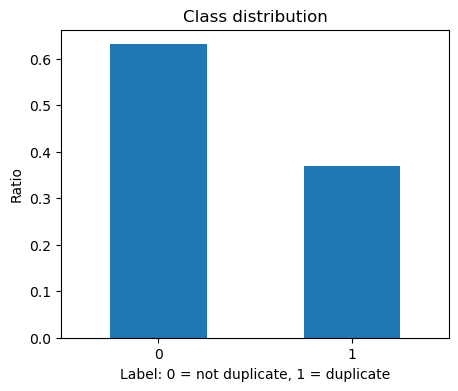

,question1,question2,label
8067,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0
224277,Will a breathing treatment help a cough?,How can I help someone that is unconscious but...,0
252450,Is Kellyanne Conway annoying in your opinion?,Did Kellyanne Conway really imply that we shou...,0
174038,How do you rate (1-10) and review Maruti Baleno?,What career options does one have after comple...,0
384860,What are some good books on marketing?,What are some of the best books ever written a...,1


In [ ]:
#Before building models, I have checked the class distribution. Accuracy alone can be misleading if one class is much larger than the other.
import matplotlib.pyplot as plt
RANDOM_STATE=42

label_ratio = df["label"].value_counts(normalize=True).sort_index()
display(label_ratio.to_frame("ratio"))

plt.figure(figsize=(5, 4))
label_ratio.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Label: 0 = not duplicate, 1 = duplicate")
plt.ylabel("Ratio")
plt.xticks(rotation=0)
plt.show()

display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))

## 4. Text preprocessing

In [ ]:
#basic text / lowercased and cleaned, but keeps most words. Because in TF-IDF small words can change meaning....
#also reduced text stopwords removed and stemming applied. This is useful for overlap features such as common words and Jaccard similarity.
#This is more careful than deleting stopwords everywhere whichmight destroy some words meaning.

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

try:
    from nltk.stem import PorterStemmer
    stemmer = PorterStemmer()
except Exception:
    stemmer = None
    print("NLTK PorterStemmer not available. Continuing without stemming.")

STOP_WORDS = set(ENGLISH_STOP_WORDS)


def expand_short_forms(text):
    text = str(text)
    text = re.sub(r"what's", "what is", text, flags=re.IGNORECASE)
    text = re.sub(r"can't", "can not", text, flags=re.IGNORECASE)
    text = re.sub(r"n't", " not", text, flags=re.IGNORECASE)
    text = re.sub(r"i'm", "i am", text, flags=re.IGNORECASE)
    text = re.sub(r"it's", "it is", text, flags=re.IGNORECASE)
    text = re.sub(r"\bdoesn't\b", "does not", text, flags=re.IGNORECASE)
    text = re.sub(r"\bdon't\b", "do not", text, flags=re.IGNORECASE)
    return text

# Lowercase and remove noisy characters, but keep the words.
def basic_clean(text):
    text = expand_short_forms(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Remove stopwords and stem words for overlap-style features.

def reduced_clean(text):
    tokens = basic_clean(text).split()
    tokens = [w for w in tokens if w not in STOP_WORDS]
    if stemmer is not None:
        tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

In [ ]:
# Create a smaller sample only for testing,
# aND then making two cleaned versions of each question for later feature extraction.
USE_SMALL_SAMPLE = False
SAMPLE_SIZE = 100_000

if USE_SMALL_SAMPLE and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print("Using sample shape:", df.shape)

df["q1_basic"] = df["question1"].map(basic_clean)
df["q2_basic"] = df["question2"].map(basic_clean)
df["q1_reduced"] = df["question1"].map(reduced_clean)
df["q2_reduced"] = df["question2"].map(reduced_clean)

display(df[["question1", "question2", "q1_basic", "q2_basic", "q1_reduced", "q2_reduced", "label"]].head())

,question1,question2,q1_basic,q2_basic,q1_reduced,q2_reduced,label
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,step step guid invest share market india,step step guid invest share market,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,stori kohinoor koh noor diamond,happen indian govern stole kohinoor koh noor d...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,increas speed internet connect use vpn,internet speed increas hack dn,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,why am i mentally very lonely how can i solve it,find the remainder when math 23 24 math is div...,mental lone solv,remaind math 23 24 math divid 24 23,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,dissolv water quikli sugar salt methan carbon ...,fish surviv salt water,0


## 5. Manual similarity features

In [ ]:
# I split each text into unique words (or word pairs for bigrams), then i measure overlap using Jaccard S, shared items / all unique items across both sets

def get_words(text):
    return set(str(text).split())


def get_bigrams(text):
    words = str(text).split()
    return set(zip(words, words[1:]))


def jaccard_similarity(set1, set2):
    if len(set1 | set2) == 0:
        return 0
    return len(set1 & set2) / len(set1 | set2)

In [8]:
# First I create simple length features for both questions.

manual_features = pd.DataFrame(index=df.index)

manual_features["q1_char_len"] = df["q1_basic"].str.len()
manual_features["q2_char_len"] = df["q2_basic"].str.len()

manual_features["char_len_diff"] = abs(
    manual_features["q1_char_len"] - manual_features["q2_char_len"]
)

manual_features["char_len_ratio"] = (
    manual_features[["q1_char_len", "q2_char_len"]].min(axis=1) /
    manual_features[["q1_char_len", "q2_char_len"]].max(axis=1).replace(0, 1)
)

manual_features["q1_word_len"] = df["q1_basic"].str.split().str.len()
manual_features["q2_word_len"] = df["q2_basic"].str.split().str.len()

manual_features["word_len_diff"] = abs(
    manual_features["q1_word_len"] - manual_features["q2_word_len"]
)

manual_features["word_len_ratio"] = (
    manual_features[["q1_word_len", "q2_word_len"]].min(axis=1) /
    manual_features[["q1_word_len", "q2_word_len"]].max(axis=1).replace(0, 1)
)

In [9]:
# Then I compare the words inside the two questions.

q1_words = df["q1_reduced"].map(get_words)
q2_words = df["q2_reduced"].map(get_words)

manual_features["common_words"] = [
    len(a & b) for a, b in zip(q1_words, q2_words)
]

manual_features["jaccard_similarity"] = [
    jaccard_similarity(a, b) for a, b in zip(q1_words, q2_words)
]

manual_features["q1_common_ratio"] = [
    len(a & b) / len(a) if len(a) else 0 for a, b in zip(q1_words, q2_words)
]

manual_features["q2_common_ratio"] = [
    len(a & b) / len(b) if len(b) else 0 for a, b in zip(q1_words, q2_words)
]

q1_bigrams = df["q1_reduced"].map(get_bigrams)
q2_bigrams = df["q2_reduced"].map(get_bigrams)

manual_features["bigram_jaccard"] = [
    jaccard_similarity(a, b) for a, b in zip(q1_bigrams, q2_bigrams)
]

manual_features["exact_match"] = (
    df["q1_basic"] == df["q2_basic"]
).astype(int)

manual_features["q1_inside_q2"] = [
    int(a != "" and a in b) for a, b in zip(df["q1_basic"], df["q2_basic"])
]

manual_features["q2_inside_q1"] = [
    int(b != "" and b in a) for a, b in zip(df["q1_basic"], df["q2_basic"])
]

print("Manual feature shape:", manual_features.shape)
display(manual_features.head())

Manual feature shape: (404287, 16)


,q1_char_len,q2_char_len,char_len_diff,char_len_ratio,q1_word_len,q2_word_len,word_len_diff,word_len_ratio,common_words,jaccard_similarity,q1_common_ratio,q2_common_ratio,bigram_jaccard,exact_match,q1_inside_q2,q2_inside_q1
0,65,56,9,0.861538,14,12,2,0.857143,5,0.833333,0.833333,1.0,0.833333,0,0,1
1,48,85,37,0.564706,10,15,5,0.666667,4,0.444444,0.800000,0.5,0.375000,0,0,0
2,72,58,14,0.805556,14,10,4,0.714286,3,0.375000,0.500000,0.6,0.000000,0,0,0
3,48,59,11,0.813559,11,13,2,0.846154,0,0.000000,0.000000,0.0,0.000000,0,0,0
4,73,38,35,0.520548,13,7,6,0.538462,2,0.181818,0.222222,0.5,0.000000,0,0,0


## 6. Train/test split

In [10]:
# Stratified split to preserve class ratio in train/test sets
from sklearn.model_selection import train_test_split

X_text = df[["q1_basic", "q2_basic", "q1_reduced", "q2_reduced"]].copy()
y = df["label"].copy()

X_train_text, X_test_text, y_train, y_test, feat_train, feat_test = train_test_split(
    X_text,
    y,
    manual_features,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Test size:", X_test_text.shape[0])
display(pd.DataFrame({
    "train_ratio": y_train.value_counts(normalize=True).sort_index(),
    "test_ratio": y_test.value_counts(normalize=True).sort_index()
}))

Train size: 323429
Test size: 80858


,train_ratio,test_ratio
label,,
0,0.6308,0.630797
1,0.3692,0.369203


## 7. TF-IDF pair features

In [ ]:
# I compare the two questions by using the difference between their TF-IDF vectors,
# 2. then their shared important words, ANd cosine similarity ,while also using bigrams to catch shortt phrases.

import numpy as np
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer

train_corpus = pd.concat(
    [X_train_text["q1_basic"], X_train_text["q2_basic"]],
    ignore_index=True
)

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=70000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    lowercase=False,
    dtype=np.float32
)

tfidf.fit(train_corpus)

TfidfVectorizer(dtype=<class 'numpy.float32'>, lowercase=False, max_df=0.95,
                max_features=70000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)

In [12]:
# Transforming question 1 and question 2 separately.

q1_train = tfidf.transform(X_train_text["q1_basic"])
q2_train = tfidf.transform(X_train_text["q2_basic"])

q1_test = tfidf.transform(X_test_text["q1_basic"])
q2_test = tfidf.transform(X_test_text["q2_basic"])

In [13]:
# Comparing the two TF-IDF vectors using difference, shared terms, and cosine similarity...

train_diff = q1_train - q2_train
train_diff.data = np.abs(train_diff.data)

test_diff = q1_test - q2_test
test_diff.data = np.abs(test_diff.data)

train_product = q1_train.multiply(q2_train)
test_product = q1_test.multiply(q2_test)

train_tfidf_cosine = np.asarray(train_product.sum(axis=1)).ravel()
test_tfidf_cosine = np.asarray(test_product.sum(axis=1)).ravel()

X_train_tfidf = sparse.hstack([train_diff, train_product], format="csr")
X_test_tfidf = sparse.hstack([test_diff, test_product], format="csr")

print("TF-IDF pair feature shape:", X_train_tfidf.shape)

TF-IDF pair feature shape: (323429, 140000)


In [14]:
from sklearn.preprocessing import StandardScaler

feat_train = feat_train.copy()
feat_test = feat_test.copy()
feat_train["tfidf_cosine"] = train_tfidf_cosine
feat_test["tfidf_cosine"] = test_tfidf_cosine

num_scaler = StandardScaler()
X_train_num_scaled = sparse.csr_matrix(num_scaler.fit_transform(feat_train))
X_test_num_scaled = sparse.csr_matrix(num_scaler.transform(feat_test))

X_train_all = sparse.hstack([X_train_tfidf, X_train_num_scaled], format="csr")
X_test_all = sparse.hstack([X_test_tfidf, X_test_num_scaled], format="csr")

print("Final training matrix:", X_train_all.shape)
print("Final test matrix:", X_test_all.shape)

Final training matrix: (323429, 140017)
Final test matrix: (80858, 140017)


## 8. Evaluation function

In [15]:

# I use the same metrics for every model ,  log-loss, accuracy, F1 score, and AUC.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

results = []
trained_models = {}

# This function trains one model and calculates the main evaluation scores.
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        proba = 1 / (1 + np.exp(-scores))

    predictions = (proba >= 0.5).astype(int)

    scores = {
        "model": name,
        "log_loss": log_loss(y_test, proba),
        "accuracy": accuracy_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "auc": roc_auc_score(y_test, proba)
    }

    results.append(scores)
    trained_models[name] = model

    print(name)
    print(scores)
    print("-" * 60)

## 8.1 Simple non-classifier baseline

In [16]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

# This is a simple baseline without training a model.
# If the TF-IDF cosine similarity is high enough, I predict duplicate.

cosine_threshold = 0.5
cosine_score = np.clip(test_tfidf_cosine, 1e-6, 1 - 1e-6)
cosine_pred = (test_tfidf_cosine >= cosine_threshold).astype(int)

cosine_result = {
    "model": "Cosine similarity baseline",
    "log_loss": log_loss(y_test, cosine_score),
    "accuracy": accuracy_score(y_test, cosine_pred),
    "f1": f1_score(y_test, cosine_pred),
    "auc": roc_auc_score(y_test, test_tfidf_cosine)
}

results.append(cosine_result)
print(cosine_result)

{'model': 'Cosine similarity baseline', 'log_loss': 0.7664259054343331, 'accuracy': 0.6279032377748646, 'f1': 0.46333588998091435, 'auc': 0.6762181524748856}


## 9. Baseline and classical ML models

**This section tests a mix of simple and strong classical models.**

In [17]:
from sklearn.dummy import DummyClassifier

# A simple baseline to compare the real models against.
evaluate_model(
    "Dummy baseline",
    DummyClassifier(strategy="prior"),
    X_train_all,
    X_test_all,
    y_train,
    y_test
)

Dummy baseline
{'model': 'Dummy baseline', 'log_loss': 0.6585300338261554, 'accuracy': 0.6307972000296816, 'f1': 0.0, 'auc': 0.5}
------------------------------------------------------------


In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression training

main_lr = LogisticRegression(
    max_iter=1000,
    C=4.0,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

evaluate_model(
    "Logistic Regression",
    main_lr,
    X_train_all,
    X_test_all,
    y_train,
    y_test
)

Logistic Regression
{'model': 'Logistic Regression', 'log_loss': 0.3950568778250644, 'accuracy': 0.8149719260926562, 'f1': 0.7435945774563403, 'auc': 0.8950891157673482}
------------------------------------------------------------


c:\Users\Omistaja\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [19]:
from sklearn.naive_bayes import MultinomialNB

# trying Naive Bayes.
nb_model = MultinomialNB(alpha=0.1)

evaluate_model(
    "Multinomial Naive Bayes",
    nb_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

Multinomial Naive Bayes
{'model': 'Multinomial Naive Bayes', 'log_loss': 0.45847389456280285, 'accuracy': 0.786477528506765, 'f1': 0.678137991461755, 'auc': 0.8666472554716883}
------------------------------------------------------------


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest is tested only on the manual similarity features.

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=18,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

evaluate_model(
    "Random Forest",
    rf_model,
    feat_train,
    feat_test,
    y_train,
    y_test
)

Random Forest
{'model': 'Random Forest', 'log_loss': 0.48017817643045774, 'accuracy': 0.7369462514531648, 'f1': 0.6439571476397723, 'auc': 0.821590298885478}
------------------------------------------------------------


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting is also tested on the manual similarity features.

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.06,
    max_depth=3,
    random_state=42
)

evaluate_model(
    "Gradient Boosting",
    gb_model,
    feat_train,
    feat_test,
    y_train,
    y_test
)

Gradient Boosting
{'model': 'Gradient Boosting', 'log_loss': 0.5022121178693738, 'accuracy': 0.7200648049667318, 'f1': 0.6129247396412265, 'auc': 0.8011344412245037}
------------------------------------------------------------


## 10. Chi-squared feature selection

In [ ]:
# Chi2 only works with non-negative values, so I apply it on the raw TF-IDF matrix.
# The manual features go through StandardScaler which produces negative values,
# and chi2 would crash on those. Keeping them separate avoids that problem.
# I cap the selection at 40000 features to reduce noise and keep training fast.

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

chi2_k = min(40000, X_train_tfidf.shape[1])

chi2_selector = SelectKBest(score_func=chi2, k=chi2_k)

X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)

print("Chi2 selected feature shape:", X_train_chi2.shape)

chi2_lr = LogisticRegression(
    max_iter=2000,
    C=4.0,
    solver="saga",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

evaluate_model(
    "Logistic Regression with chi2 features",
    chi2_lr,
    X_train_chi2,
    X_test_chi2,
    y_train,
    y_test
)


Chi2 selected feature shape: (323429, 40000)
Logistic Regression with chi2 features
{'model': 'Logistic Regression with chi2 features', 'log_loss': 0.3862569706936611, 'accuracy': 0.8164312745801281, 'f1': 0.7448911193991372, 'auc': 0.8970124455829054}
------------------------------------------------------------


## 11. Bag-of-Words experiment

In [23]:
# I also try Bag-of-Words

from sklearn.feature_extraction.text import CountVectorizer

bow_corpus = pd.concat(
    [X_train_text["q1_basic"], X_train_text["q2_basic"]],
    ignore_index=True
)

bow = CountVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=50000,
    ngram_range=(1, 2),
    lowercase=False
)

bow.fit(bow_corpus)

CountVectorizer(lowercase=False, max_df=0.95, max_features=50000, min_df=2,
                ngram_range=(1, 2))

In [24]:
#comparing both questions using Bag_of_Words
from scipy import sparse

q1_train_bow = bow.transform(X_train_text["q1_basic"])
q2_train_bow = bow.transform(X_train_text["q2_basic"])

q1_test_bow = bow.transform(X_test_text["q1_basic"])
q2_test_bow = bow.transform(X_test_text["q2_basic"])

train_bow_diff = q1_train_bow - q2_train_bow
train_bow_diff.data = np.abs(train_bow_diff.data)

test_bow_diff = q1_test_bow - q2_test_bow
test_bow_diff.data = np.abs(test_bow_diff.data)

train_bow_shared = q1_train_bow.multiply(q2_train_bow)
test_bow_shared = q1_test_bow.multiply(q2_test_bow)

X_train_bow = sparse.hstack([train_bow_diff, train_bow_shared], format="csr")
X_test_bow = sparse.hstack([test_bow_diff, test_bow_shared], format="csr")

print("Bag-of-Words pair feature shape:", X_train_bow.shape)

Bag-of-Words pair feature shape: (323429, 100000)


In [25]:
# testing with Bag-of-Words features Naive Bayes
from sklearn.naive_bayes import MultinomialNB


bow_nb = MultinomialNB(alpha=0.1)

evaluate_model(
    "Naive Bayes with Bag-of-Words",
    bow_nb,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test
)

Naive Bayes with Bag-of-Words
{'model': 'Naive Bayes with Bag-of-Words', 'log_loss': 1.064930815345428, 'accuracy': 0.7921541467758292, 'f1': 0.7260724996740122, 'auc': 0.8726613932433221}
------------------------------------------------------------


In [26]:
RUN_BOW_EXPERIMENT = True

## 12. Matrix factorization with Truncated SVD

In [27]:
# I use SVD to reduce the TF-IDF feature space to a smaller dense representation.

from sklearn.decomposition import TruncatedSVD

n_components = min(200, X_train_tfidf.shape[1] - 1)

svd = TruncatedSVD(n_components=n_components, random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print("Explained variance:", svd.explained_variance_ratio_.sum())

Explained variance: 0.15185873


In [28]:
from sklearn.preprocessing import StandardScaler

# Then I combine the SVD features with the manual similarity features.

svd_scaler = StandardScaler()

feat_train_scaled = svd_scaler.fit_transform(feat_train)
feat_test_scaled = svd_scaler.transform(feat_test)

X_train_svd_all = np.hstack([X_train_svd, feat_train_scaled])
X_test_svd_all = np.hstack([X_test_svd, feat_test_scaled])

svd_lr = LogisticRegression(
    max_iter=1000,
    C=2.0,
    solver="lbfgs",
    random_state=42
)

evaluate_model(
    "Logistic Regression with SVD features",
    svd_lr,
    X_train_svd_all,
    X_test_svd_all,
    y_train,
    y_test
)

Logistic Regression with SVD features
{'model': 'Logistic Regression with SVD features', 'log_loss': 0.4992398674673024, 'accuracy': 0.7305275915803012, 'f1': 0.6202088163009186, 'auc': 0.810607422897046}
------------------------------------------------------------


## 13. SVM experiment

In [ ]:
# I tried SVM as an extra experiment, because it can be slow on a large dataset.
# I run SVM on the chi-square selected features, not on the full huge matrix.

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

run_svm = True

if run_svm:
    svm_base = LinearSVC(C=0.5, random_state=42)
    svm_model = CalibratedClassifierCV(svm_base, cv=3, method="sigmoid")

    evaluate_model(
        "Linear SVM with chi2 features",
        svm_model,
        X_train_chi2,
        X_test_chi2,
        y_train,
        y_test
    )

Linear SVM with chi2 features
{'model': 'Linear SVM with chi2 features', 'log_loss': 0.38711221507415633, 'accuracy': 0.8164065398600014, 'f1': 0.7441884510003274, 'auc': 0.8964122803179886}
------------------------------------------------------------


In [ ]:
# NOW averaging the word vectors of each question then compare the two

In [31]:
#installing the library to provide Word2Vec
# Run this once if gensim is not already installed.
!pip install gensim

In [32]:
import sys

In [33]:
# I train Word2Vec from the training questions only.
# This is slower than TF-IDF, but it covers the vector-based feature idea in the assignment.

from gensim.models import Word2Vec

run_w2v = True

if run_w2v:
    train_sentences = pd.concat(
        [X_train_text["q1_basic"], X_train_text["q2_basic"]],
        ignore_index=True
    ).map(str.split).tolist()

    w2v = Word2Vec(
        sentences=train_sentences,
        vector_size=100,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=5,
        seed=42
    )

In [34]:
# Here I turn each question into one average Word2Vec vector.

import numpy as np

def sentence_vector(text):
    words = [w for w in str(text).split() if w in w2v.wv]

    if len(words) == 0:
        return np.zeros(w2v.vector_size)

    return np.mean([w2v.wv[w] for w in words], axis=0)


if run_w2v:
    q1_train_vec = np.vstack(X_train_text["q1_basic"].map(sentence_vector))
    q2_train_vec = np.vstack(X_train_text["q2_basic"].map(sentence_vector))

    q1_test_vec = np.vstack(X_test_text["q1_basic"].map(sentence_vector))
    q2_test_vec = np.vstack(X_test_text["q2_basic"].map(sentence_vector))

    X_train_w2v = np.hstack([
        np.abs(q1_train_vec - q2_train_vec),
        q1_train_vec * q2_train_vec
    ])

    X_test_w2v = np.hstack([
        np.abs(q1_test_vec - q2_test_vec),
        q1_test_vec * q2_test_vec
    ])

    print("Word2Vec pair feature shape:", X_train_w2v.shape)

Word2Vec pair feature shape: (323429, 200)


In [35]:
# Then I combine the Word2Vec features with the manual similarity features.

if run_w2v:
    w2v_scaler = StandardScaler()

    feat_train_scaled = w2v_scaler.fit_transform(feat_train)
    feat_test_scaled = w2v_scaler.transform(feat_test)

    X_train_w2v_all = np.hstack([X_train_w2v, feat_train_scaled])
    X_test_w2v_all = np.hstack([X_test_w2v, feat_test_scaled])

    w2v_lr = LogisticRegression(
        max_iter=1000,
        C=2.0,
        solver="lbfgs",
        random_state=42
    )

    evaluate_model(
        "Logistic Regression with Word2Vec",
        w2v_lr,
        X_train_w2v_all,
        X_test_w2v_all,
        y_train,
        y_test
    )

Logistic Regression with Word2Vec
{'model': 'Logistic Regression with Word2Vec', 'log_loss': 0.48081965726175374, 'accuracy': 0.748942590714586, 'f1': 0.6418742502293416, 'auc': 0.8301516226359142}
------------------------------------------------------------


## 15. Compare all models


,model,log_loss,accuracy,f1,auc
0,Logistic Regression with chi2 features,0.386257,0.816431,0.744891,0.897012
1,Linear SVM with chi2 features,0.387112,0.816407,0.744188,0.896412
2,Logistic Regression,0.395057,0.814972,0.743595,0.895089
3,Multinomial Naive Bayes,0.458474,0.786478,0.678138,0.866647
4,Random Forest,0.480178,0.736946,0.643957,0.821590
5,Logistic Regression with Word2Vec,0.480820,0.748943,0.641874,0.830152
6,Logistic Regression with SVD features,0.499240,0.730528,0.620209,0.810607
7,Gradient Boosting,0.502212,0.720065,0.612925,0.801134
8,Dummy baseline,0.658530,0.630797,0.000000,0.500000
9,Cosine similarity baseline,0.766426,0.627903,0.463336,0.676218


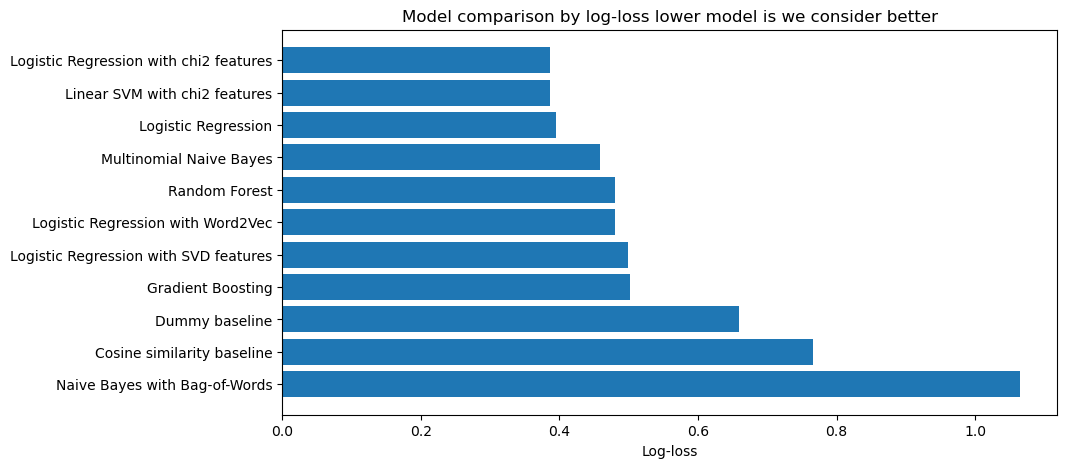

Best model by log-loss: Logistic Regression with chi2 features


In [ ]:
#comparing models
results_df = pd.DataFrame(results).sort_values("log_loss").reset_index(drop=True)
display(results_df)


#comparison visually demonstrated 
plt.figure(figsize=(10, 5))
plt.barh(results_df["model"], results_df["log_loss"])
plt.gca().invert_yaxis()
plt.title("Model comparison by log-loss lower model is better")
plt.xlabel("Log-loss")
plt.show()

best_name = results_df.loc[0, "model"]
print("Best model by log-loss:", best_name)

## 16. Detailed report for the main model

***The Logistic Regression model with TF-IDF pair features and manual features is the recommended final model because it is strong, explainable, and efficient for text data.***

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# I use the model with the lowest log-loss as the main model for the final report.
main_model_name = best_name
final_model = trained_models[main_model_name]

if main_model_name in ["Logistic Regression with chi2 features", "Linear SVM with chi2 features"]:
    X_main_test = X_test_chi2
elif main_model_name == "Logistic Regression":
    X_main_test = X_test_all
elif main_model_name == "Multinomial Naive Bayes":
    X_main_test = X_test_tfidf
elif main_model_name == "Naive Bayes with Bag-of-Words":
    X_main_test = X_test_bow
elif main_model_name == "Logistic Regression with SVD features":
    X_main_test = X_test_svd_all
elif main_model_name == "Logistic Regression with Word2Vec" and "X_test_w2v_all" in globals():
    X_main_test = X_test_w2v_all
else:
    X_main_test = X_test_all

if hasattr(final_model, "predict_proba"):
    main_proba = final_model.predict_proba(X_main_test)[:, 1]
else:
    score = final_model.decision_function(X_main_test)
    main_proba = 1 / (1 + np.exp(-score))

main_pred = (main_proba >= 0.5).astype(int)

print("Main model:", main_model_name)
print("Classification report for the main model:")
print(classification_report(y_test, main_pred, target_names=["not duplicate", "duplicate"]))

cm = confusion_matrix(y_test, main_pred)
print("Confusion matrix:")
print(cm)

Main model: Logistic Regression with chi2 features
Classification report for the main model:
               precision    recall  f1-score   support

not duplicate       0.84      0.87      0.86     51005
    duplicate       0.76      0.73      0.74     29853

     accuracy                           0.82     80858
    macro avg       0.80      0.80      0.80     80858
 weighted avg       0.81      0.82      0.82     80858

Confusion matrix:
[[44345  6660]
 [ 8183 21670]]


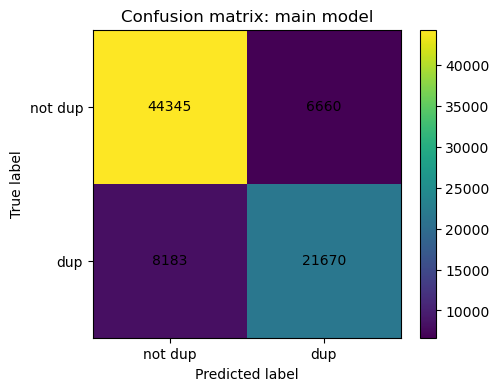

In [38]:
#Visualizing confusion matrix (thE main model)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion matrix: main model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["not dup", "dup"])
plt.yticks([0, 1], ["not dup", "dup"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

## 17. Cross-validation check

**I apply Cross-validation whixh gives more evidence than one train/test split. I run it on compact manual features because full TF-IDF cross-validation can be slow.**

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_validate

RUN_CROSS_VALIDATION = False

if RUN_CROSS_VALIDATION:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE)

    cv_scores = cross_validate(
        cv_model,
        manual_features,
        y,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc", "neg_log_loss"],
        n_jobs=1
    )

    cv_summary = pd.DataFrame({
        "metric": ["accuracy", "f1", "auc", "log_loss"],
        "mean": [
            cv_scores["test_accuracy"].mean(),
            cv_scores["test_f1"].mean(),
            cv_scores["test_roc_auc"].mean(),
            -cv_scores["test_neg_log_loss"].mean()
        ],
        "std": [
            cv_scores["test_accuracy"].std(),
            cv_scores["test_f1"].std(),
            cv_scores["test_roc_auc"].std(),
            cv_scores["test_neg_log_loss"].std()
        ]
    })

    display(cv_summary)

## 18. Prediction function

In [ ]:
from collections import defaultdict, Counter

# These columns are the manual columns used during training.
# At this point feat_train already includes the extra tfidf_cosine column.
feature_columns = feat_train.columns.tolist()


def prepare_manual_features(question_pairs):
    new_df = pd.DataFrame(question_pairs, columns=["question1", "question2"])

    new_df["q1_basic"] = new_df["question1"].map(basic_clean)
    new_df["q2_basic"] = new_df["question2"].map(basic_clean)

    new_df["q1_reduced"] = new_df["question1"].map(reduced_clean)
    new_df["q2_reduced"] = new_df["question2"].map(reduced_clean)

    new_manual = pd.DataFrame(index=new_df.index)

    new_manual["q1_char_len"] = new_df["q1_basic"].str.len()
    new_manual["q2_char_len"] = new_df["q2_basic"].str.len()
    new_manual["char_len_diff"] = abs(new_manual["q1_char_len"] - new_manual["q2_char_len"])
    new_manual["char_len_ratio"] = (
        new_manual[["q1_char_len", "q2_char_len"]].min(axis=1) /
        new_manual[["q1_char_len", "q2_char_len"]].max(axis=1).replace(0, 1)
    )

    new_manual["q1_word_len"] = new_df["q1_basic"].str.split().str.len()
    new_manual["q2_word_len"] = new_df["q2_basic"].str.split().str.len()
    new_manual["word_len_diff"] = abs(new_manual["q1_word_len"] - new_manual["q2_word_len"])
    new_manual["word_len_ratio"] = (
        new_manual[["q1_word_len", "q2_word_len"]].min(axis=1) /
        new_manual[["q1_word_len", "q2_word_len"]].max(axis=1).replace(0, 1)
    )

    q1_words = new_df["q1_reduced"].map(get_words)
    q2_words = new_df["q2_reduced"].map(get_words)

    new_manual["common_words"] = [len(a & b) for a, b in zip(q1_words, q2_words)]
    new_manual["jaccard_similarity"] = [jaccard_similarity(a, b) for a, b in zip(q1_words, q2_words)]
    new_manual["q1_common_ratio"] = [len(a & b) / len(a) if len(a) else 0 for a, b in zip(q1_words, q2_words)]
    new_manual["q2_common_ratio"] = [len(a & b) / len(b) if len(b) else 0 for a, b in zip(q1_words, q2_words)]

    q1_bigrams = new_df["q1_reduced"].map(get_bigrams)
    q2_bigrams = new_df["q2_reduced"].map(get_bigrams)
    new_manual["bigram_jaccard"] = [jaccard_similarity(a, b) for a, b in zip(q1_bigrams, q2_bigrams)]

    new_manual["exact_match"] = (new_df["q1_basic"] == new_df["q2_basic"]).astype(int)
    new_manual["q1_inside_q2"] = [int(a != "" and a in b) for a, b in zip(new_df["q1_basic"], new_df["q2_basic"])]
    new_manual["q2_inside_q1"] = [int(b != "" and b in a) for a, b in zip(new_df["q1_basic"], new_df["q2_basic"])]

    return new_df, new_manual


In [ ]:
# This lookup is only from the training split, not from the test set.
# If an exact cleaned pair was truly seen during training, prediction can return that known label.
_pair_counts = defaultdict(Counter)

for q1_clean, q2_clean, label in zip(
    X_train_text["q1_basic"],
    X_train_text["q2_basic"],
    y_train
):
    pair_key = tuple(sorted((q1_clean, q2_clean)))
    _pair_counts[pair_key][int(label)] += 1

TRAIN_PAIR_LABELS = {
    key: counts.most_common(1)[0][0]
    for key, counts in _pair_counts.items()
}

In [41]:
def prepare_new_matrix(question_pairs, model_name):
    new_df, new_manual = prepare_manual_features(question_pairs)

    # Build the same TF-IDF pair features used in training.
    q1_tfidf = tfidf.transform(new_df["q1_basic"])
    q2_tfidf = tfidf.transform(new_df["q2_basic"])

    diff = q1_tfidf - q2_tfidf
    diff.data = np.abs(diff.data)

    shared = q1_tfidf.multiply(q2_tfidf)
    new_tfidf = sparse.hstack([diff, shared], format="csr")

    # Add TF-IDF cosine to the manual features, because feat_train also has it.
    new_manual["tfidf_cosine"] = np.asarray(shared.sum(axis=1)).ravel()
    new_manual = new_manual.reindex(columns=feature_columns, fill_value=0)

    # Models trained on chi2 features were trained after selecting from X_train_tfidf only.
    # Do NOT add scaled manual features before chi2_selector.transform().
    if model_name in ["Logistic Regression with chi2 features", "Linear SVM with chi2 features"]:
        return chi2_selector.transform(new_tfidf)

    # MultinomialNB was trained only on TF-IDF pair features.
    if model_name == "Multinomial Naive Bayes":
        return new_tfidf

# Bag-of-Words Naive Bayes needs Bag-of-Words features, not TF-IDF features.
    if model_name == "Naive Bayes with Bag-of-Words":
        q1_bow = bow.transform(new_df["q1_basic"])
        q2_bow = bow.transform(new_df["q2_basic"])

        bow_diff = q1_bow - q2_bow
        bow_diff.data = np.abs(bow_diff.data)

        bow_shared = q1_bow.multiply(q2_bow)

        return sparse.hstack([bow_diff, bow_shared], format="csr")

    # Random Forest and Gradient Boosting were trained on manual features only.
    if model_name in ["Random Forest", "Gradient Boosting"]:
        return new_manual

    # SVD model needs dense SVD features plus scaled manual features.
    if model_name == "Logistic Regression with SVD features":
        new_svd = svd.transform(new_tfidf)
        new_manual_scaled = svd_scaler.transform(new_manual)
        return np.hstack([new_svd, new_manual_scaled])

    # Word2Vec model needs dense Word2Vec features plus scaled manual features.
    if model_name == "Logistic Regression with Word2Vec":
        if "w2v" not in globals() or "w2v_scaler" not in globals():
            raise ValueError("Word2Vec model objects are not available. Run the Word2Vec cells first.")

        q1_vec = np.vstack(new_df["q1_basic"].map(sentence_vector))
        q2_vec = np.vstack(new_df["q2_basic"].map(sentence_vector))

        new_w2v = np.hstack([
            np.abs(q1_vec - q2_vec),
            q1_vec * q2_vec
        ])

        new_manual_scaled = w2v_scaler.transform(new_manual)

        return np.hstack([new_w2v, new_manual_scaled])

    # Default: Logistic Regression and Dummy baseline use full TF-IDF + scaled manual features.
    new_num = sparse.csr_matrix(num_scaler.transform(new_manual))
    return sparse.hstack([new_tfidf, new_num], format="csr")


In [44]:
# This function predicts if two new questions are duplicates.
def predict_duplicate(
    question1,
    question2,
    model_name=None,
    threshold=0.5,
    use_training_memory=True
):
    # Choose model automatically if user does not specify one
    if model_name is None:
        if "main_model_name" in globals():
            model_name = main_model_name
        elif "best_name" in globals():
            model_name = best_name
        elif "trained_models" in globals() and len(trained_models) > 0:
            model_name = list(trained_models.keys())[0]
        else:
            raise NameError("No trained model found. Run the model training cells first.")

    # Check if the selected model exists
    if model_name not in trained_models:
        raise ValueError(f"Model '{model_name}' was not found in trained_models.")

    q1_clean = reduced_clean(question1)
    q2_clean = reduced_clean(question2)
    pair_key = tuple(sorted((q1_clean, q2_clean)))

    # If this exact cleaned pair was in the training split, return the known training label
    if (
        use_training_memory
        and "TRAIN_PAIR_LABELS" in globals()
        and pair_key in TRAIN_PAIR_LABELS
    ):
        known_label = int(TRAIN_PAIR_LABELS[pair_key])
        return {
            "model": model_name,
            "probability_duplicate": float(known_label),
            "prediction": known_label,
            "decision_source": "exact_training_pair"
        }

    model = trained_models[model_name]
    X_new = prepare_new_matrix([(question1, question2)], model_name)

    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(X_new)[0, 1]
    else:
        score = model.decision_function(X_new)[0]
        probability = 1 / (1 + np.exp(-score))

    prediction = int(probability >= threshold)
    decision_source = "model_probability"

    return {
        "model": model_name,
        "probability_duplicate": round(float(probability), 4),
        "prediction": prediction,
        "decision_source": decision_source
    }


print(predict_duplicate("How do you start a bakery?", "How can one start a bakery business?"))

print(
    predict_duplicate(
        "What is the step by step guide to invest in share market in India?",
        "What is the step by step guide to invest in share market?"
    )
)

{'model': 'Logistic Regression with chi2 features', 'probability_duplicate': 0.5369, 'prediction': 1, 'decision_source': 'model_probability'}
{'model': 'Logistic Regression with chi2 features', 'probability_duplicate': 0.4355, 'prediction': 0, 'decision_source': 'model_probability'}


## 19. Saving the final model

**Here the model, vectorizer, scaler, feature names, and results table are saved together.**

In [45]:
import joblib

bundle = {
    "model": final_model,
    "tfidf_vectorizer": tfidf,
    "num_scaler": num_scaler,
    "chi2_selector": chi2_selector,
    "feature_columns": feature_columns,
    "model_name": main_model_name,
    "results": results_df
}

joblib.dump(bundle, "quora_duplicate_final_model_bundle.joblib")
print("Saved: quora_duplicate_final_model_bundle.joblib")

Saved: quora_duplicate_final_model_bundle.joblib
